# Tree counting

I am interested in the space of unlabeled, unrooted trees. To manipulate existing class amd math structure to serve my purposes, I add a group action and quotient metric to BHV space (the space of semi-labelled, unrooted trees), so that I am looking at the space of semi-labelled, unrooted trees, invariant to label permutations (ie, the space of unlabeled, unrooted trees). There is likely a better way to do this. 

This notebook will be structured as follows:
1. Load this space, show a few examples with a new Tree-visualisation function.
2. Count trees in this space for n=[3,8] leaves. This aligns with topological analysis using generating functions by Cropper in 1997, showing how Geomstats can be used to do math.
3. Visualise these trees using Multi-dimensional scaling.
4. Compute distances and the mean in this space (using a mangled, iterative, Procrustesesque computation).





## 0. Imports

In [53]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import itertools
import random
import pandas as pd

import geomstats.backend as gs
from geomstats.geometry.stratified.bhv_space import (
    Tree,
    TreeSpace,
)
from geomstats.geometry.stratified.trees import (
    Split,
    generate_splits,
    generate_n_splits,
)
from geomstats.learning.frechet_mean import SturmsMean

gs.random.seed(666)

## 1. Unlabelled BHV Space

In [2]:
n_bhv5_space = 5

total_bhv5_space = TreeSpace(n_labels=n_bhv5_space)
total_bhv5_space.equip_with_group_action()

label_invariant_bhv5_space = total_bhv5_space.equip_with_quotient()

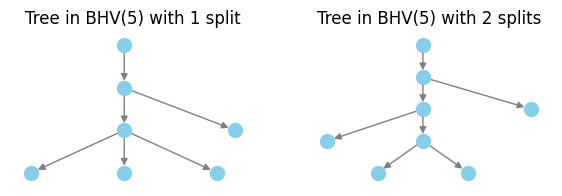

In [3]:
max_n_interior_edges = n_bhv5_space - 3

fig, axes = plt.subplots(1, max_n_interior_edges, figsize=(7, 2))
for i in range(max_n_interior_edges):
    n_splits = i + 1
    splits = generate_n_splits(list(range(n_bhv5_space)), n_splits)
    new_tree = Tree(splits, [1 for _ in range(n_splits)])

    ax = axes[i]
    new_tree.plot(ax=ax)
    ax.set_title(
        f"Tree in BHV({n_bhv5_space}) with {n_splits} split{'' if n_splits == 1 else 's'}"
    )
plt.show()

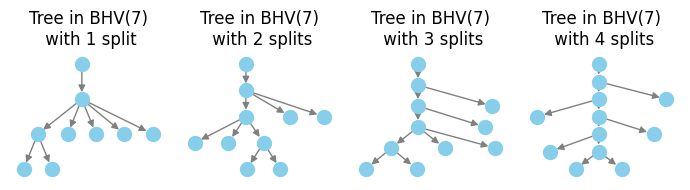

In [4]:
n_bhv7_space = 7

total_bhv7_space = TreeSpace(n_labels=n_bhv7_space)
total_bhv7_space.equip_with_group_action()

label_invariant_bhv7_space = total_bhv5_space.equip_with_quotient()

max_n_interior_edges = n_bhv7_space - 3
fig, axes = plt.subplots(1, max_n_interior_edges, figsize=(7, 2))
for i in range(max_n_interior_edges):
    n_splits = i + 1
    splits = generate_n_splits(list(range(n_bhv7_space)), n_splits)
    new_tree = Tree(splits, [1 for _ in range(n_splits)])

    ax = axes[i]
    new_tree.plot(ax=ax)
    ax.set_title(
        f"Tree in BHV({n_bhv7_space})\n with {n_splits} split{'' if n_splits == 1 else 's'}"
    )
plt.tight_layout()
plt.show()

## 2. Counting unlabeled, unrooted trees 

Using recursive nested parentheses representation (AHU; see https://arxiv.org/pdf/2401.07636)

EX: (((),()),((),(),())) is same as {1,2}|{3,4,5}

In [45]:
def get_distinct_unlabeled_trees_ahu(n_bhv_space, n_interior_edges, n_iter=1000):
    bhv_to_ahu = {}
    seen_ahu = set()

    for _ in range(n_iter):
        splits = generate_n_splits(list(range(n_bhv_space)), n_interior_edges)
        lengths = gs.ones(n_interior_edges)

        new_tree = Tree(splits, lengths)
        new_tree_ahu_strs = new_tree.get_all_possible_ahus()

        if not new_tree_ahu_strs & seen_ahu:
            bhv_to_ahu[new_tree] = new_tree_ahu_strs
            seen_ahu = seen_ahu | new_tree_ahu_strs
    return bhv_to_ahu

In [ ]:
bhv_ns = range(4, 12)

distinct_bhv_trees = {x: {} for x in bhv_ns}
for n_bhv_space in bhv_ns:
    print(f"Starting BHV({n_bhv_space})...", end="\t")

    total_space = TreeSpace(n_labels=n_bhv_space)
    total_space.equip_with_group_action()
    label_invariant_tree_space = total_space.equip_with_quotient()

    star = total_space.star_tree()
    distinct_bhv_trees[n_bhv_space][0] = {star: star.get_all_possible_ahus()}
    print(1, end=" ")
    for n_int_edges in range(1, n_bhv_space - 2):
        distinct_bhv_ahu = get_distinct_unlabeled_trees_ahu(
            n_bhv_space, n_int_edges, n_iter=100 * (n_bhv_space**2)
        )
        distinct_bhv_trees[n_bhv_space][n_int_edges] = distinct_bhv_ahu
        print(len(distinct_bhv_ahu), end=" ")
    print()

Starting BHV(4)...	1 1 
Starting BHV(5)...	1 1 1 
Starting BHV(6)...	1 2 2 2 
Starting BHV(7)...	1 2 4 4 2 
Starting BHV(8)...	1 3 6 10 8 4 
Starting BHV(9)...	1 3 9 17 22 15 6 
Starting BHV(10)...	1 4 12 30 47 53 32 11 
Starting BHV(11)...	1 4 16 44 91 127 121 66 18 


### Counts
Counts of unique unlabeled, unrooted trees by N labels (rows) and m interior edges (columns). Taken from (Cropper 1997; Appendix 1)[https://combinatorialpress.com/article/jcmcc/Volume%20024/vol-24-paper%2013.pdf]. N\in[4,8] are replicated above/below using geomstats.

N labels \\ m edges|0|1|2|3|4|5|6|7|8
---|---|---|---|---|---|---|---|---|---|
4|1|1
5|1|1|1
6|1|2|2|2
7|1|2|4|4|2
8|1|3|6|10|8|4
9|1|3|9|17|22|15|6
10|1|4|12|30|47|53|32|11
11|1|4|16|44|91|127|121|66|18

multinomial distribution

[1, 1]
[1, 1, 1]
[1, 2, 2, 2]
[1, 2, 4, 4, 2]
[1, 3, 6, 10, 8, 4]
[1, 3, 9, 17, 22, 15, 6]


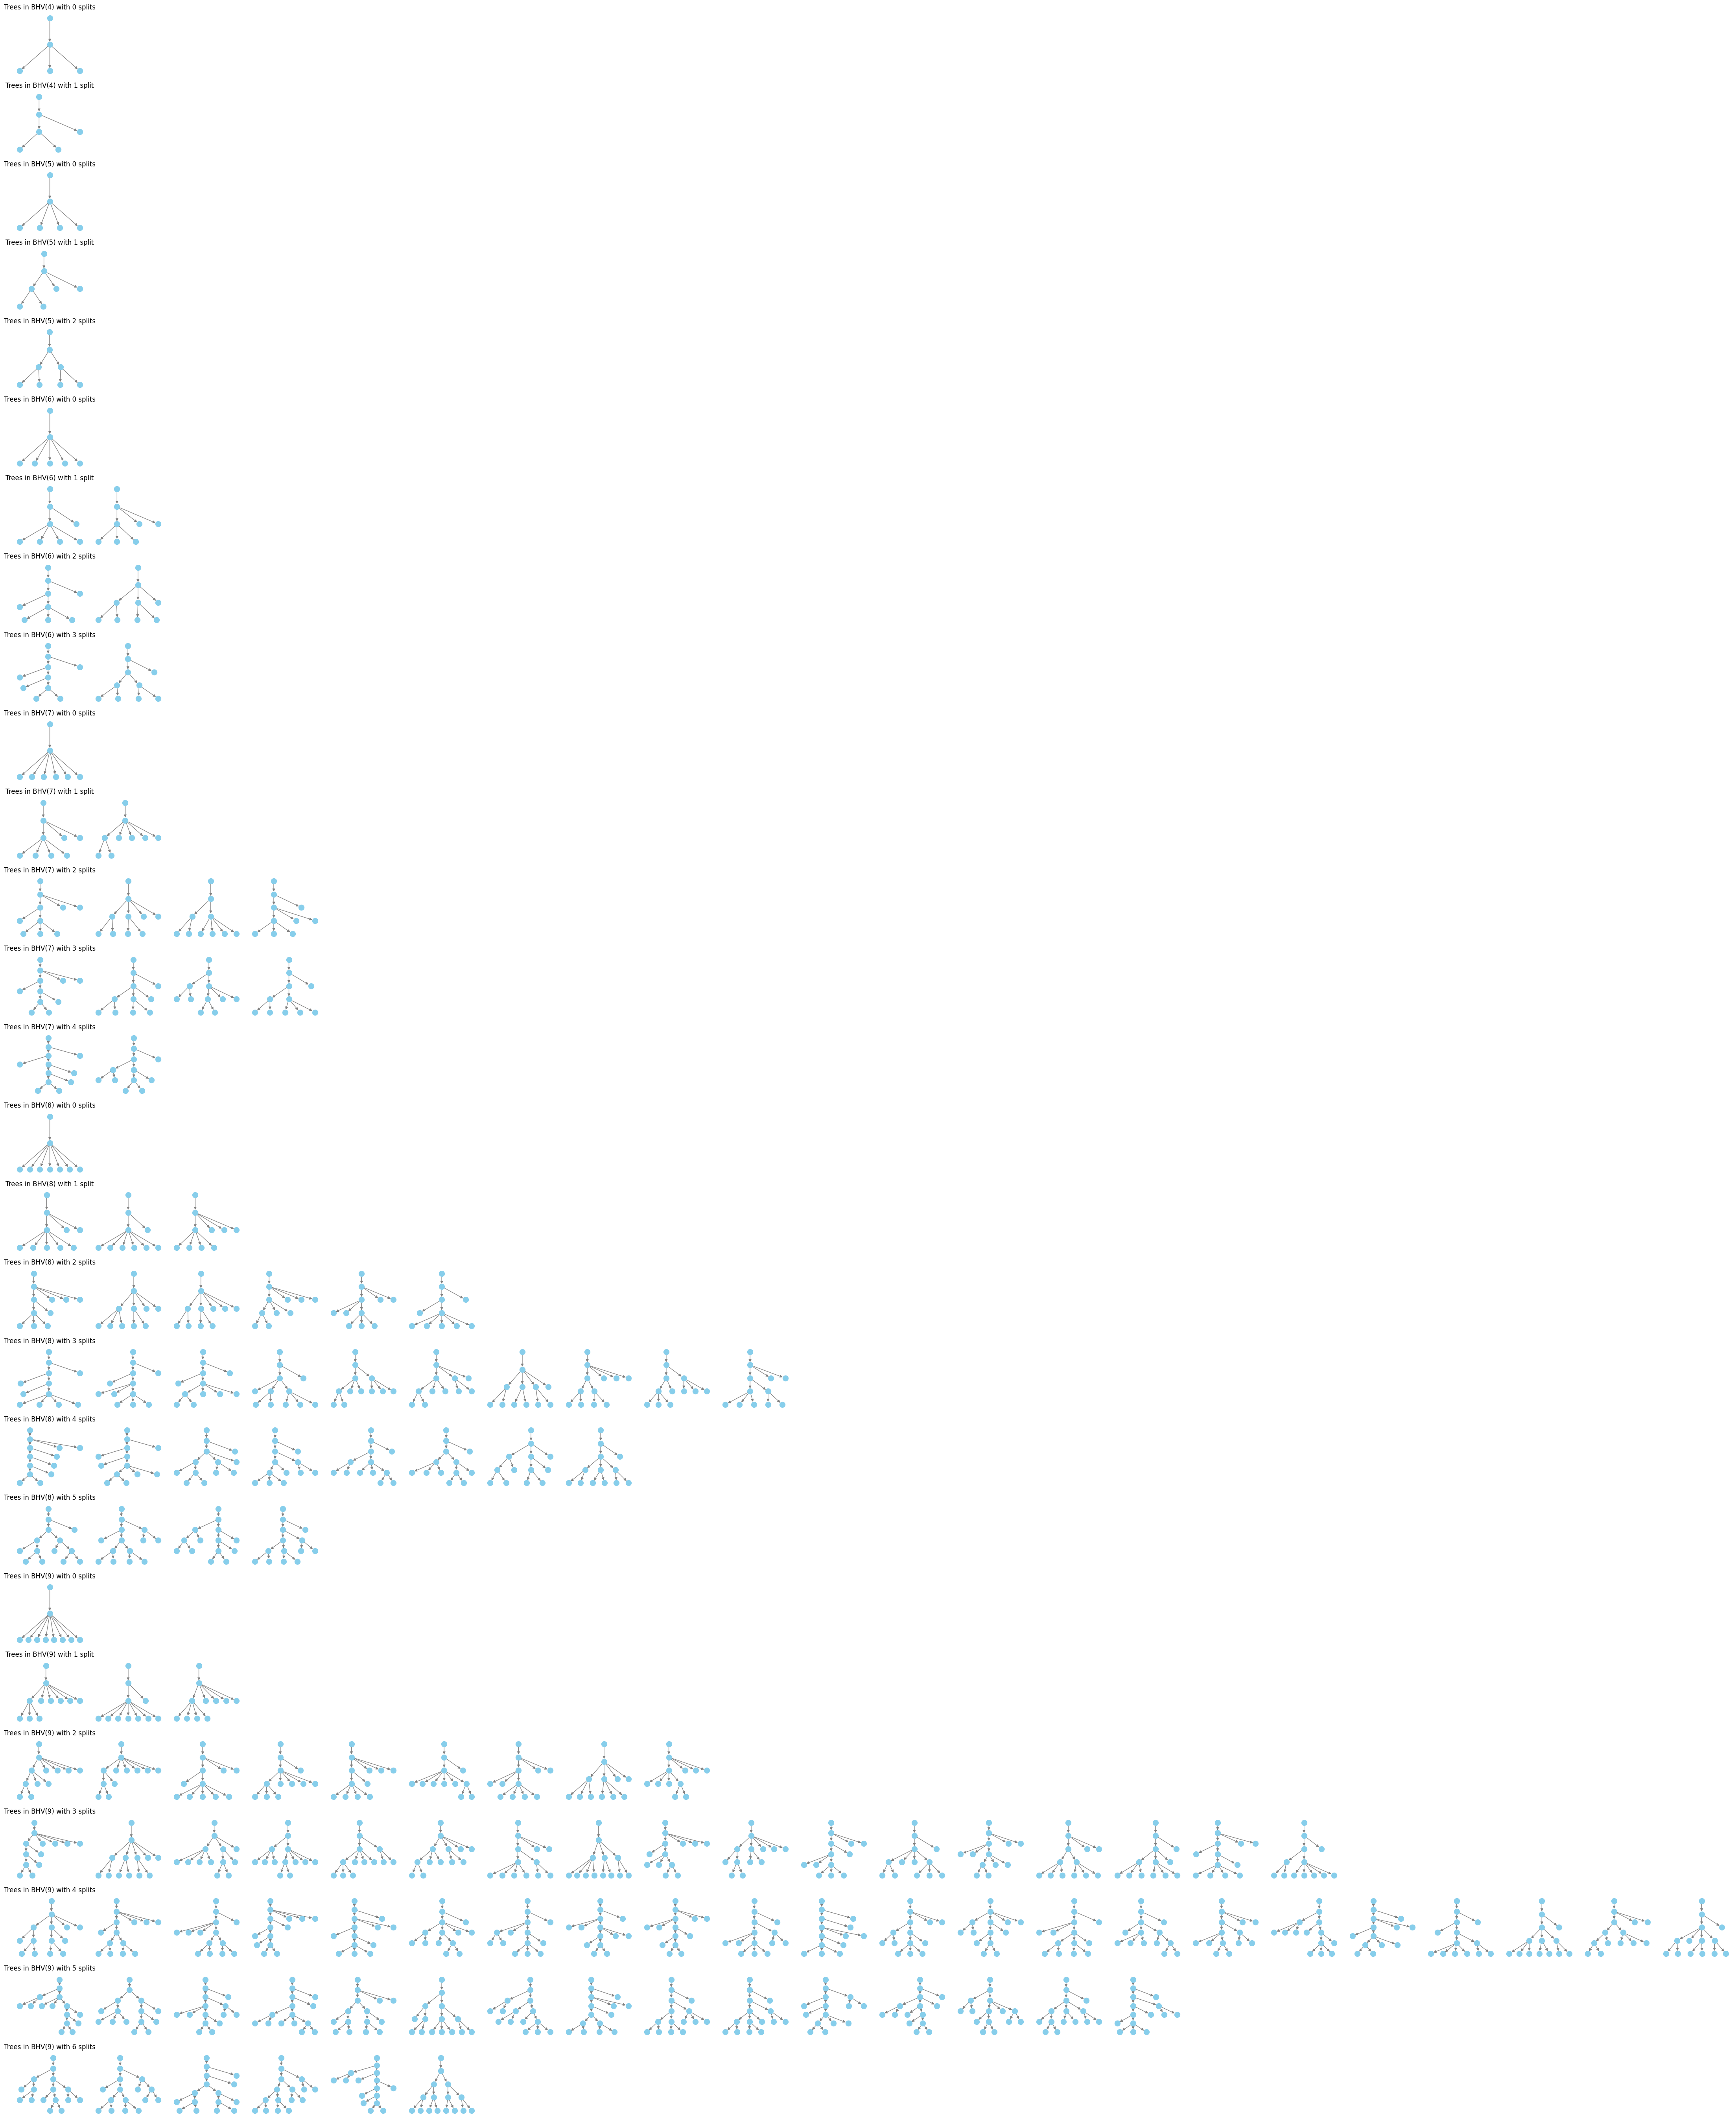

In [21]:
# plot all hehe

ns = range(4, 10)
all_counts = [[len(distinct_bhv_trees[n][i]) for i in range(0, n - 2)] for n in ns]
for ac in all_counts:
    print(ac)

n_rows, n_cols = (
    np.sum([len(x) for x in all_counts]),
    np.max([np.max(x) for x in all_counts]),
)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2, n_rows * 2))

idx = 0
for n_bhv_space in ns:
    for n_int_edges in range(0, n_bhv_space - 2):
        for i, (tr) in enumerate(distinct_bhv_trees[n_bhv_space][n_int_edges].keys()):
            ax = axes[idx][i]
            tr.plot(ax=ax)
            if i == 0:
                ax.set_title(
                    f"Trees in BHV({n_bhv_space}) with {n_int_edges} split{'' if n_int_edges == 1 else 's'}"
                )
        idx += 1

for ax in axes.ravel():
    ax.axis("off")

plt.tight_layout()
plt.show()

#### solved bug
only taking first n randomly generated splits wouldn't work

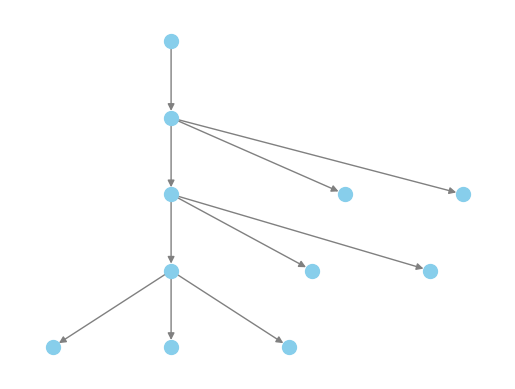

False


In [196]:
tree_not_found = Tree(
    [Split({0, 1, 2}, {3, 4, 5, 6, 7}), Split({0, 1, 2, 3, 4}, {5, 6, 7})],
    lengths=gs.ones(2),
)
tree_not_found.plot()
plt.show()

current_tree_strings = sorted(
    {x for v in new_distinct_bhv_trees[8][2].values() for x in v}
)
not_found_tree_strs = get_all_root_ahus(tree_not_found)

tree_already_exists = False
for tree_str in not_found_tree_strs:
    if tree_str in current_tree_strings:
        tree_already_exists = True
        print(tree_str)

print(tree_already_exists)

In [198]:
for _ in range(100000):
    splits = random.sample(generate_splits(list(range(8)), exclude_singletons=True), 2)
    # splits = [Split({0, 1, 2}, {3, 4, 5, 6, 7}), Split({0, 1, 2, 3, 4}, {5, 6, 7})]

    s0_small = splits[0].part1 if len(splits[0].part1) < 4 else splits[0].part2
    s0_big = splits[0].part2 if len(splits[0].part1) < 4 else splits[0].part1

    s1_small = splits[1].part1 if len(splits[1].part1) < 4 else splits[1].part2
    s1_big = splits[1].part2 if len(splits[1].part1) < 4 else splits[1].part1

    if (len(s0_small) == 3) and (len(s1_small) == 3):
        if (s1_small < s0_big) and (s0_small < s1_big):
            print("yay!", splits)
    # break

yay! [({0, 4, 7}, {1, 2, 3, 5, 6}), ({0, 2, 3, 4, 7}, {1, 5, 6})]
yay! [({0, 1, 3, 4, 5}, {2, 6, 7}), ({0, 2, 3, 6, 7}, {1, 4, 5})]
yay! [({0, 4, 6}, {1, 2, 3, 5, 7}), ({0, 1, 3, 4, 6}, {2, 5, 7})]
yay! [({0, 2, 3, 5, 7}, {1, 4, 6}), ({0, 3, 7}, {1, 2, 4, 5, 6})]
yay! [({0, 1, 2}, {3, 4, 5, 6, 7}), ({0, 1, 2, 4, 7}, {3, 5, 6})]
yay! [({0, 1, 4, 5, 7}, {2, 3, 6}), ({0, 1, 5}, {2, 3, 4, 6, 7})]
yay! [({0, 1, 4, 5, 7}, {2, 3, 6}), ({0, 4, 7}, {1, 2, 3, 5, 6})]
yay! [({0, 5, 6}, {1, 2, 3, 4, 7}), ({0, 3, 4, 5, 6}, {1, 2, 7})]
yay! [({0, 2, 4, 5, 7}, {1, 3, 6}), ({0, 1, 3, 5, 6}, {2, 4, 7})]
yay! [({0, 3, 4, 6, 7}, {1, 2, 5}), ({0, 4, 6}, {1, 2, 3, 5, 7})]
yay! [({0, 3, 5}, {1, 2, 4, 6, 7}), ({0, 2, 3, 5, 7}, {1, 4, 6})]
yay! [({0, 1, 3}, {2, 4, 5, 6, 7}), ({0, 1, 2, 3, 4}, {5, 6, 7})]
yay! [({0, 1, 2, 3, 7}, {4, 5, 6}), ({0, 3, 4, 5, 6}, {1, 2, 7})]
yay! [({0, 1, 5}, {2, 3, 4, 6, 7}), ({0, 1, 2, 3, 5}, {4, 6, 7})]
yay! [({0, 1, 3, 6, 7}, {2, 4, 5}), ({0, 2, 3, 4, 5}, {1, 6, 7})]
yay! [({0,

(({0, 1, 4, 5}|{2, 3, 6, 7}, {0, 1, 5}|{2, 3, 4, 6, 7});[1. 1.])
{'(((((),(),()),()),(),(),()))': 0, '(((((),(),(),()),()),(),()))': 1, '((((),(),()),((),(),(),())))': 4}


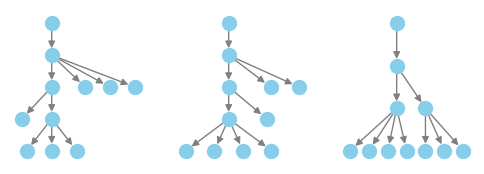

(({0, 1, 2, 3, 5, 6}|{4, 7}, {0, 6}|{1, 2, 3, 4, 5, 7});[1. 1.])
{'(((((),()),(),(),(),()),()))': 0, '((((),()),((),()),(),(),()))': 1}


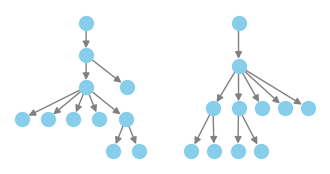

(({0, 1, 4, 5, 6}|{2, 3, 7}, {0, 1, 4, 5, 6, 7}|{2, 3});[1. 1.])
{'((((),()),((),(),(),(),())))': 0, '(((((),()),()),(),(),(),()))': 1, '(((((),(),(),(),()),()),()))': 2}


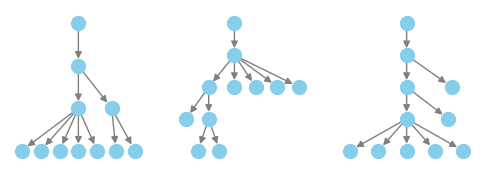

(({0, 2, 5, 6}|{1, 3, 4, 7}, {0, 2}|{1, 3, 4, 5, 6, 7});[1. 1.])
{'(((((),()),(),()),(),(),()))': 0, '(((((),(),(),()),(),()),()))': 2, '((((),()),((),(),(),()),()))': 5}


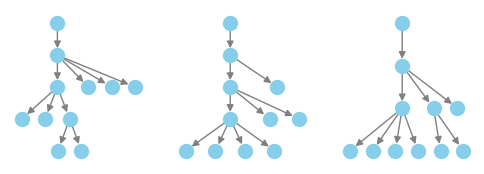

(({0, 1, 3, 5, 6, 7}|{2, 4}, {0, 1, 2, 4, 5}|{3, 6, 7});[1. 1.])
{'(((((),()),(),(),()),(),()))': 0, '((((),()),((),(),()),(),()))': 1, '(((((),(),()),(),(),()),()))': 2}


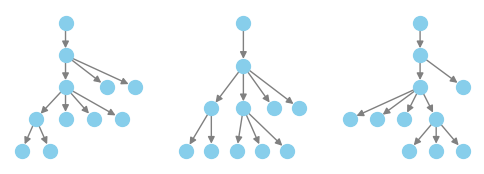

In [115]:
for tree in new_distinct_bhv_trees[8][2]:
    print(tree)

    distinct_ahus_to_root_ids = {}

    for root_id in range(8):
        nx_g = tree._to_networkx(root_id=root_id)
        ahu = encode_ahu(nx_g)
        if ahu not in distinct_ahus_to_root_ids:
            distinct_ahus_to_root_ids[ahu] = root_id
    print(distinct_ahus_to_root_ids)

    fig, axes = plt.subplots(
        1,
        len(distinct_ahus_to_root_ids),
        figsize=(len(distinct_ahus_to_root_ids) * 2, 2),
    )
    for i, root_id in enumerate(distinct_ahus_to_root_ids.values()):
        if len(distinct_ahus_to_root_ids) == 1:
            ax = axes
        else:
            ax = axes[i]

        tree.plot(root_id=root_id, ax=ax)
    plt.show()

## 2b. Initial (slow) counting trees

The generate splits (random Tree) function will generate duplicates, as it should. Given enough samples, we should span the (topological) space. Note that for BHV(n_labels=N), there are a maximum of N-3 interior edges. The algorithm here will be as follows:

* distinct_N_trees[0_edges] = {star_tree}
* For each n_interior_edges in [1,N-3]
    * distinct_N_trees[n_interior_edges] = {}
    * Generate many* sets of random splits length n_interior_edges
    * Make tree, assuming all edge lengths are one
    * Check whether this tree exists already in our set of distinct label-invariant trees, by checking whether distance using quotient metric is zero. (alt: brute force permute labels N! times and see if anything matches)
    * If we haven't seen it, add it to distinct_N_trees[n_interior_edges]
    * Boom! 

\* Many will depend on how many distinct trees of that size exist. N=8, n_interior_edges=3 yields 10. We probably need 40 random samples? Of course, this is probabilistic, so if something looks wrong, run it again. 20 is enough for N up to 6. Not enough for 7. For N=8, doing 40 samples takes ~1hr to run. Need to go through twice to get full span of trees.

In [54]:
def do_u_exist(new_boy, stable_boys, total_space):
    r"""Check whether new tree exists in a set, up to a permutation.

    Am aware this is not an excellent, but helps me return early.

    Parameters
    ----------
    root_id : int\in[0,self.topology.n_labels)
        This helps give orientation to networkx graph for visualisation. If None,
        this function assumes, rather arbitrarily, that the last label is the root.
    pendant_edges : array-like, shape=[self.topology.n_labels]
        The pendant edge lengths, a vector containing positive numbers.
    ax : plt axis
    """
    if len(stable_boys) == 0:
        return False

    for perm in total_space.aligner.align_algo._perms:
        relabeled = total_space.group_action(perm, new_boy)
        for stable_tree in stable_boys:
            if total_space.metric.dist(stable_tree, relabeled) < 0.1:
                return True
    return False


def do_u_exist_faster(new_boy, stable_boys, total_space):
    """Check whether new tree exists in a set, all in standard basis."""
    if len(stable_boys) == 0:
        return False

    # faster exit
    new_boy_shape = []
    for ft_split_pair in new_boy.topology.splits:
        p1, p2 = ft_split_pair.part1, ft_split_pair.part2
        new_boy_shape.append(max(len(p1), len(p2)))
    new_boy_shape.sort()

    #  possible matches
    possible_matches = []
    for tree in stable_boys:
        tree_shape = []
        for ft_split_pair in tree.topology.splits:
            p1, p2 = ft_split_pair.part1, ft_split_pair.part2
            tree_shape.append(max(len(p1), len(p2)))
        tree_shape.sort()

        if tree_shape == new_boy_shape:
            possible_matches.append(tree)

    if len(possible_matches) == 0:
        return False

    # print("possible_matches", possible_matches)
    # print("my tree", new_boy)
    # print("BASES", new_boy.get_basis_trees())

    # should only consider subset of permutations that act on
    # two groups separately....???
    longest_split_basis = new_boy_shape[-1]
    for stable_tree in possible_matches:
        if new_boy.compare_in_basis_with_permutation(
            stable_tree, total_space, longest_split_basis
        ):
            return True
    return False


In [55]:
def convert_to_standard_basis(tree, total_space, by_biggest=True):
    # arbitrary just to orient
    # print(tree.topology.splits)
    splits = []
    for ft_split_pair in tree.topology.splits:
        p1, p2 = ft_split_pair.part1, ft_split_pair.part2
        if len(p1) > len(p2):
            splits.append(tuple(p1))
        else:
            splits.append(tuple(p2))

    # order by biggest into smallest
    ordered_splits = sorted(splits, key=lambda x: len(x), reverse=True)
    # print("ordered_splits", ordered_splits)

    # set biggest group to be 0...m continuous
    # ie, {a,b,c} should -> {0, 1, 2}
    biggest_split_part1 = (
        set(ordered_splits[0]) if by_biggest else set(ordered_splits[-1])
    )
    biggest_split_part2 = set(range(tree.topology.n_labels)) - biggest_split_part1

    to_swap_from_p1 = []
    for lab in biggest_split_part1:
        if lab >= len(biggest_split_part1):
            to_swap_from_p1.append(lab)
    to_swap_from_p2 = []
    for lab in biggest_split_part2:
        if lab < len(biggest_split_part1):
            to_swap_from_p2.append(lab)

    ordering_perm = list(range(tree.topology.n_labels))
    for l1, l2 in zip(to_swap_from_p1, to_swap_from_p2):
        ordering_perm[l1] = l2
        ordering_perm[l2] = l1

    relabeled = total_space.group_action(ordering_perm, tree)
    # print("perm", ordering_perm)
    # print("RELABELED", relabeled)

    # for perm in total_space.aligner.align_algo._perms:
    #     print(type(perm))

    # print(ordered_splits)
    return relabeled

In [59]:
def update_tree_counts(
    n_bhv_space, n_interior_edges, total_space, current_counts=set(), n_iter=20
):
    for _ in range(n_iter):
        splits = generate_n_splits(list(range(n_bhv_space)), n_splits=n_interior_edges)
        lengths = gs.ones(n_interior_edges)

        new_tree = Tree(splits, lengths)
        # convert_to_standard_basis(Tree(splits, lengths), total_space, by_biggest=True)
        already_exists = do_u_exist_faster(new_tree, current_counts, total_space)

        if not already_exists:
            yes_im_sure = do_u_exist(new_tree, current_counts, total_space)
            if yes_im_sure:
                print("WOW I USED THE FAILSAFE")
                print(new_tree)
                print(new_tree.compute_tree_in_standard_basis(total_space))
                print(current_counts)
            if not yes_im_sure:
                current_counts.add(new_tree)
    return current_counts

In [57]:
faster_distinct_bhv_trees = {x: {} for x in range(4, 10)}

In [ ]:
for n_bhv_space in range(4, 10):
    faster_distinct_bhv_trees[n_bhv_space][0] = {Tree([], [], n_labels=n_bhv_space)}

    total_space = TreeSpace(n_labels=n_bhv_space)
    total_space.equip_with_group_action()
    label_invariant_tree_space = total_space.equip_with_quotient()

    print(f"Starting BHV({n_bhv_space})...", end="\t")
    print(1, end=" ")

    for n_int_edges in range(1, n_bhv_space - 2):
        to_update = faster_distinct_bhv_trees[n_bhv_space].get(n_int_edges, set())
        updated_counts = update_tree_counts(
            n_bhv_space,
            n_int_edges,
            total_space=total_space,
            current_counts=to_update,
            n_iter=50,
        )
        faster_distinct_bhv_trees[n_bhv_space][n_int_edges] = updated_counts
        print(len(updated_counts), end=" ")
    print()

Starting BHV(4)...	1 1 
Starting BHV(5)...	1 1 1 
Starting BHV(6)...	1 2 2 2 
Starting BHV(7)...	1 2 4 4 2 
Starting BHV(8)...	1 3 

In [145]:
n_bhv_space = 9

total_space = TreeSpace(n_labels=n_bhv_space)
total_space.equip_with_group_action()
label_invariant_tree_space = total_space.equip_with_quotient()

distinct_bhv_N_trees = {}
# distinct_bhv_N_trees[0] = {TreeSpace.star_tree()}
for n_interior_edges in range(1, n_bhv_space - 2):
    distinct_trees_with_n_interior_edges = (
        set()
    )  # distinct_bhv_trees[n_bhv_space][n_interior_edges]
    for _ in range(20):
        splits = generate_n_splits(list(range(n_bhv_space)), n_splits=n_interior_edges)
        lengths = gs.ones(n_interior_edges)

        new_tree = convert_to_standard_basis(Tree(splits, lengths), total_space)
        # print(new_tree)
        # already_exists = do_u_exist(new_tree, distinct_trees_with_n_interior_edges, total_space)
        already_exists = do_u_exist_faster(
            new_tree, distinct_trees_with_n_interior_edges, total_space
        )
        # print(already_exists)

        if not already_exists:
            yes_im_sure = do_u_exist(
                new_tree, distinct_trees_with_n_interior_edges, total_space
            )
            if not yes_im_sure:
                distinct_trees_with_n_interior_edges.add(new_tree)
    # break
    distinct_bhv_N_trees[n_interior_edges] = distinct_trees_with_n_interior_edges
    print("done with", n_interior_edges)
distinct_bhv_trees[n_bhv_space] = distinct_bhv_N_trees

done with 1
done with 2
done with 3
done with 4
done with 5
done with 6


distinct_bhv_trees[9] {1: {((({0, 1, 2, 3, 4}, {8, 5, 6, 7}),), (np.float64(1.0),)), ((({0, 1, 2, 3, 4, 5}, {8, 6, 7}),), (np.float64(1.0),)), ((({0, 1, 2, 3, 4, 5, 6}, {8, 7}),), (np.float64(1.0),))}, 2: {((({0, 2, 3, 4, 6}, {8, 1, 5, 7}), ({0, 1, 2, 3, 4, 5, 6}, {8, 7})), (np.float64(1.0), np.float64(1.0))), ((({0, 1, 2, 3, 4}, {8, 5, 6, 7}), ({0, 2, 3, 4}, {1, 5, 6, 7, 8})), (np.float64(1.0), np.float64(1.0))), ((({0, 2, 3, 4, 5, 6}, {8, 1, 7}), ({0, 1, 2, 3, 4, 5, 6}, {8, 7})), (np.float64(1.0), np.float64(1.0))), ((({0, 1, 2, 3, 4}, {8, 5, 6, 7}), ({0, 1, 2, 3, 4, 5}, {8, 6, 7})), (np.float64(1.0), np.float64(1.0))), ((({0, 1, 2, 6}, {3, 4, 5, 7, 8}), ({0, 1, 2, 3, 4, 5, 6}, {8, 7})), (np.float64(1.0), np.float64(1.0))), ((({0, 1, 3, 5, 6, 7, 8}, {2, 4}), ({0, 1, 2, 3, 4, 5, 6}, {8, 7})), (np.float64(1.0), np.float64(1.0)))}, 3: {((({0, 2, 3, 4, 5, 6}, {8, 1, 7}), ({0, 1, 2, 3, 4, 5, 6}, {8, 7}), ({0, 2, 4, 5, 6}, {8, 1, 3, 7})), (np.float64(1.0), np.float64(1.0), np.float64(1.0))

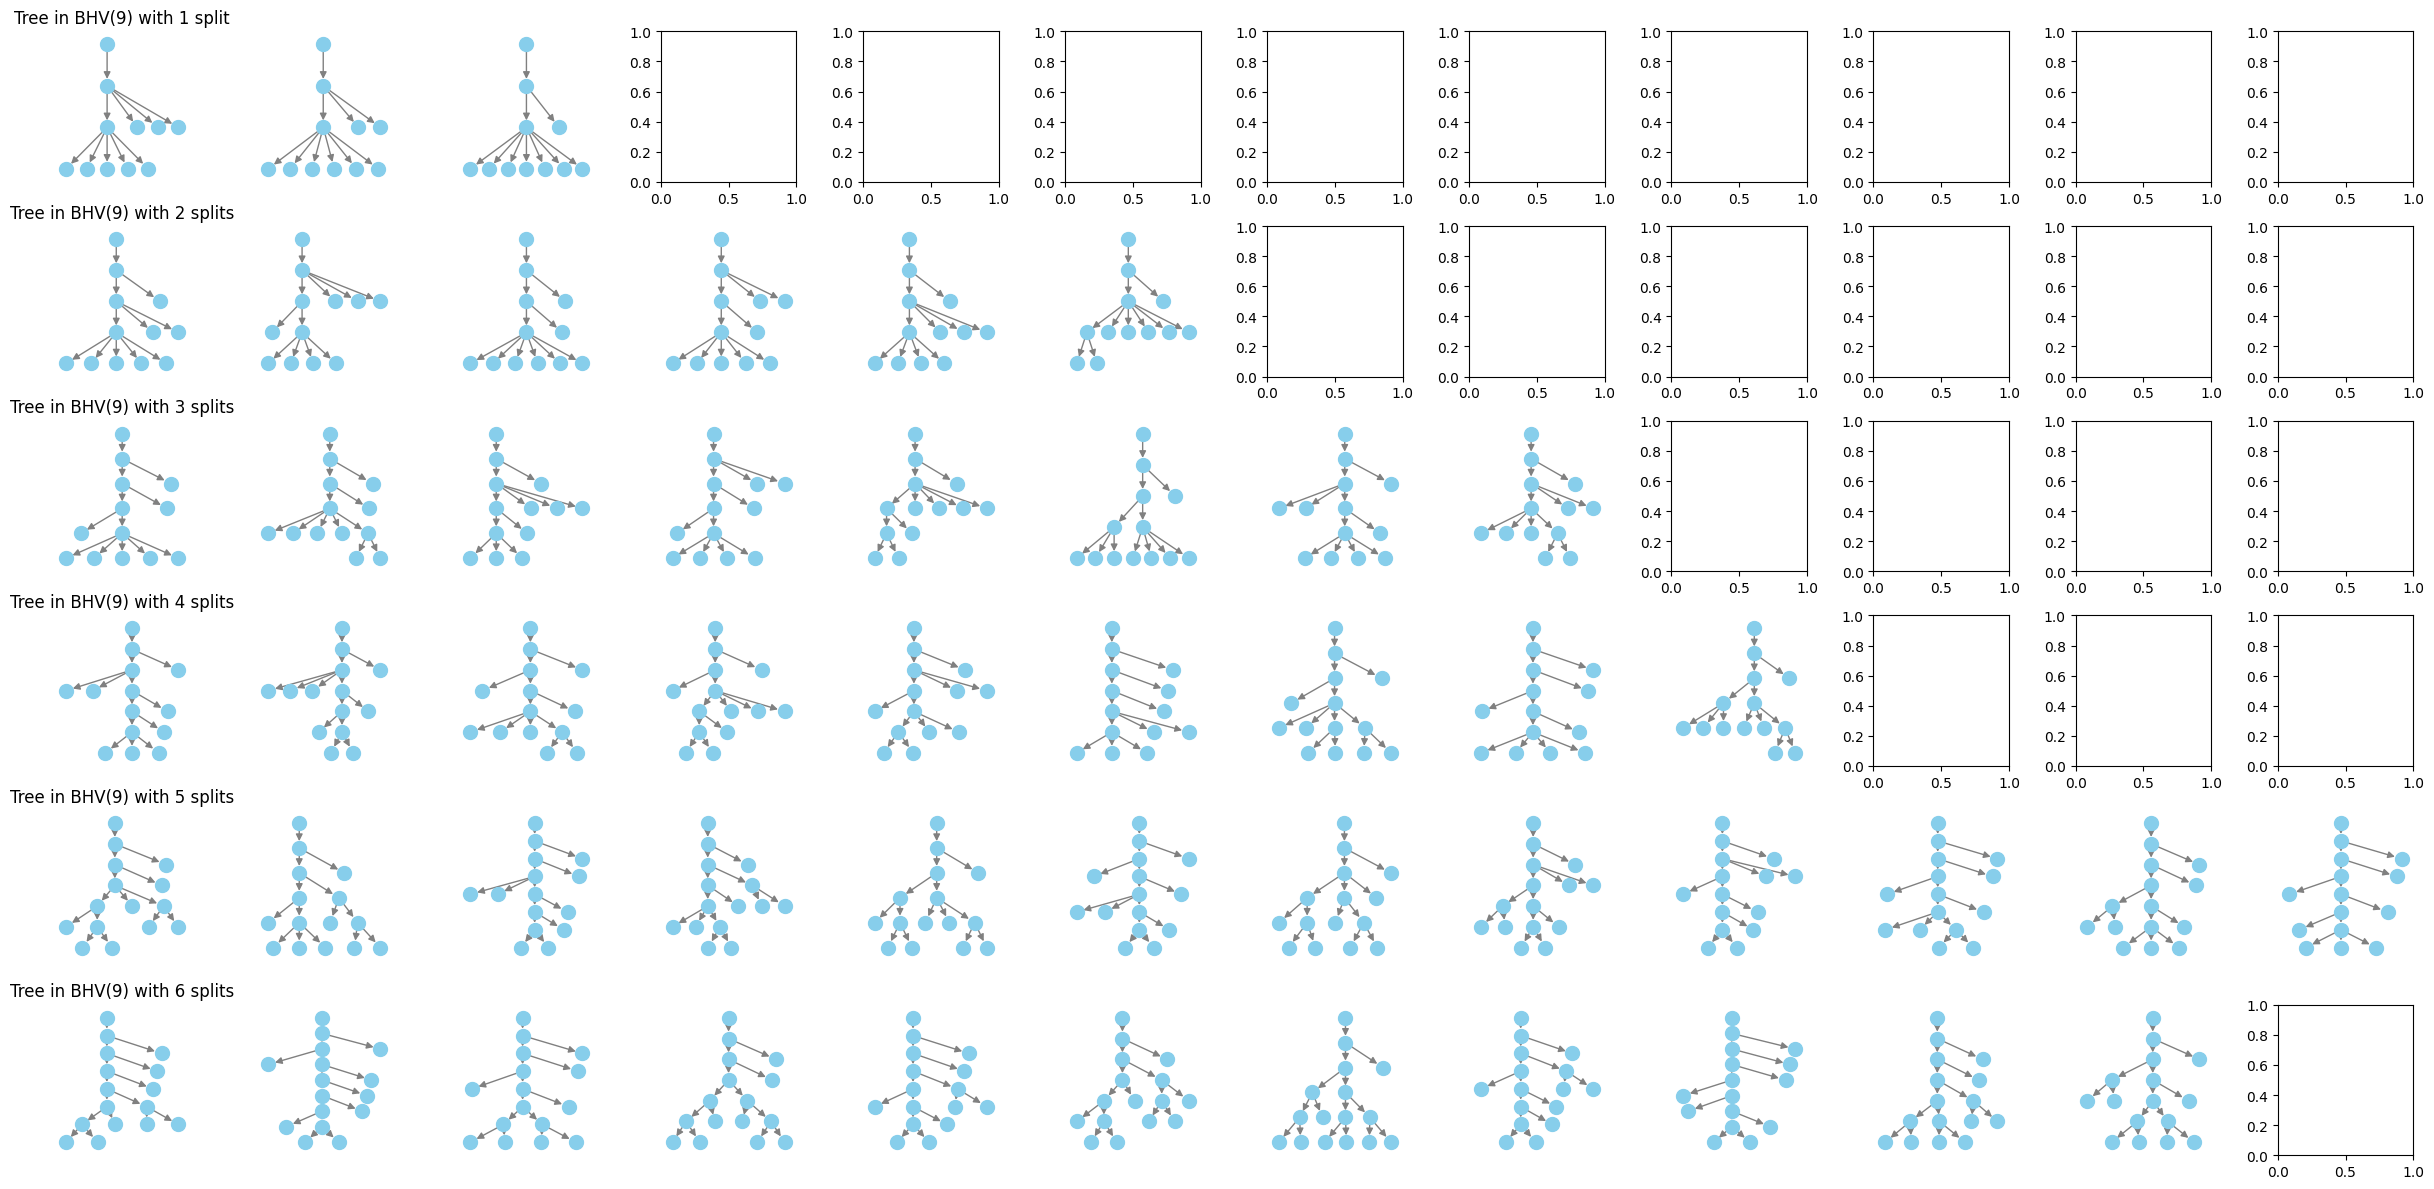

In [146]:
print(f"distinct_bhv_trees[{n_bhv_space}]", distinct_bhv_trees[n_bhv_space])
counts = [len(distinct_bhv_trees[n_bhv_space][i]) for i in range(1, n_bhv_space - 2)]
print("counts:", counts)

n_rows, n_cols = len(counts), np.max(counts)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2, n_rows * 2))

for n_int_edges in range(1, n_bhv_space - 2):
    for i, (tr) in enumerate(distinct_bhv_trees[n_bhv_space][n_int_edges]):
        if n_bhv_space == 4:
            ax = axes
        elif n_bhv_space == 5:
            ax = axes[n_int_edges - 1]
        else:
            ax = axes[n_int_edges - 1][i]
        tr.plot(ax=ax)
        if i == 0:
            ax.set_title(
                f"Tree in BHV({n_bhv_space}) with {n_int_edges} split{'' if n_int_edges == 1 else 's'}"
            )
plt.tight_layout()
plt.show()

[[1, 1], [1, 1, 1], [1, 2, 2, 2], [1, 2, 4, 3, 2], [1, 3, 5, 8, 8, 4]]


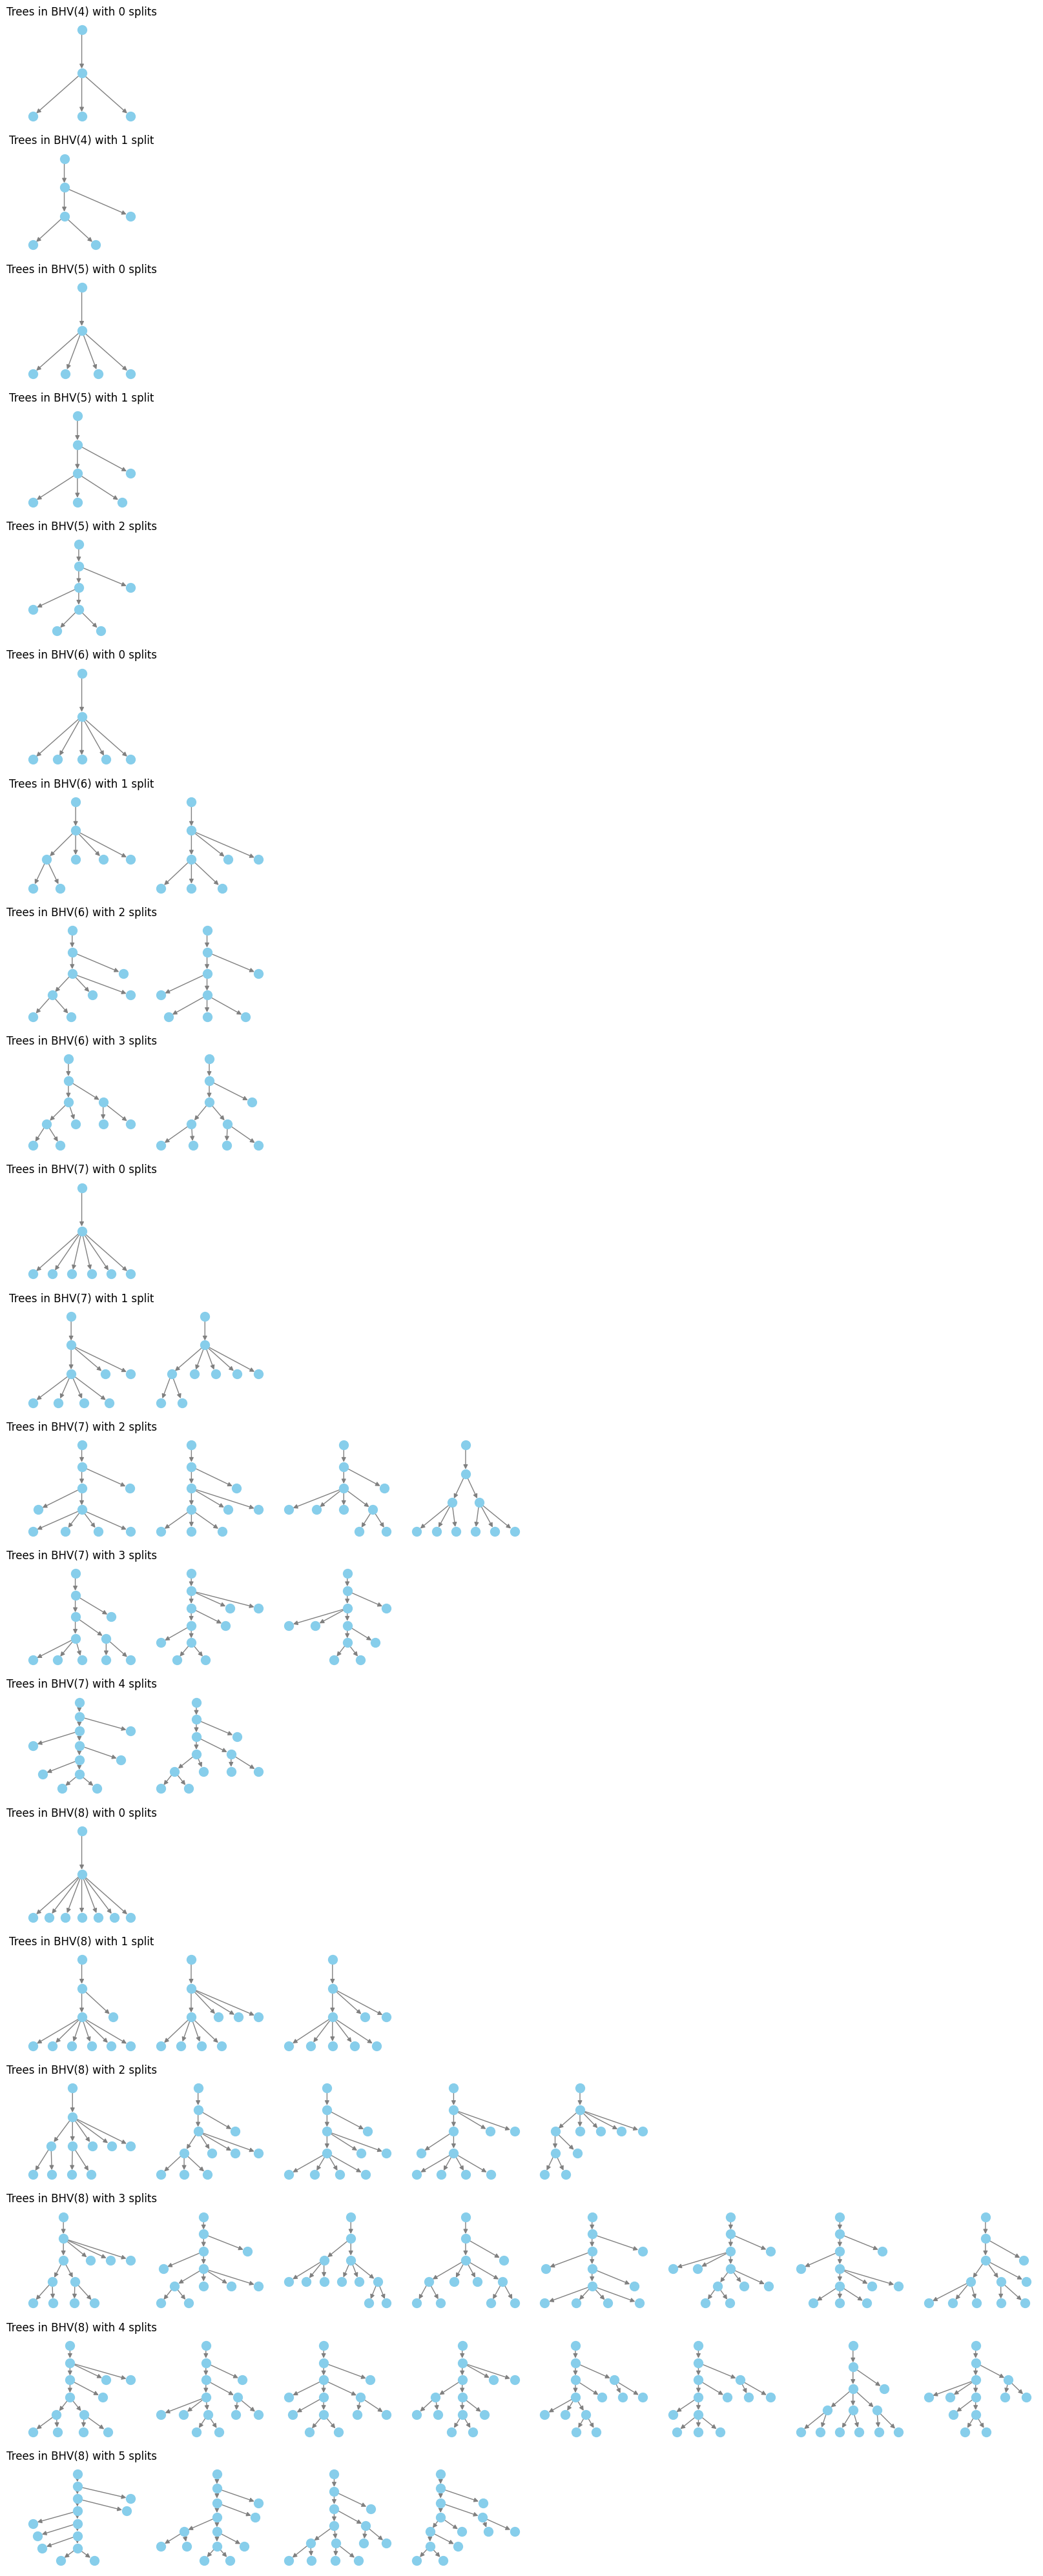

In [128]:
# plot all hehe

ns = range(4, 9)
all_counts = [
    [len(faster_distinct_bhv_trees[n][i]) for i in range(0, n - 2)] for n in ns
]
print(all_counts)

n_rows, n_cols = (
    np.sum([len(x) for x in all_counts]),
    np.max([np.max(x) for x in all_counts]),
)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2, n_rows * 2))

idx = 0
for n_bhv_space in ns:
    for n_int_edges in range(0, n_bhv_space - 2):
        for i, (tr) in enumerate(faster_distinct_bhv_trees[n_bhv_space][n_int_edges]):
            ax = axes[idx][i]
            tr.plot(ax=ax)
            if i == 0:
                ax.set_title(
                    f"Trees in BHV({n_bhv_space}) with {n_int_edges} split{'' if n_int_edges == 1 else 's'}"
                )
        idx += 1

for ax in axes.ravel():
    ax.axis("off")

plt.tight_layout()
plt.show()

## 3. Compute mean

In [58]:
bhv_ft = TreeSpace(n_labels=fewest_attempts + 1)  # for root

bhv_ft.equip_with_group_action()
bhv_ft.equip_with_quotient()

sturms_mean = SturmsMean(bhv_ft, max_iter=3000, align_iter=4, epsilon=1e-3)

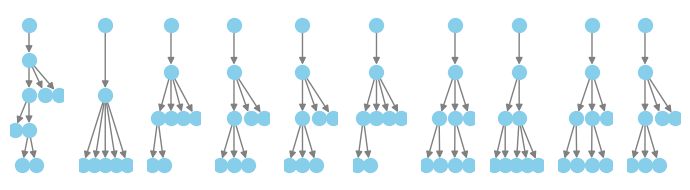

In [60]:
# Visualise trees
trees = np.array([x for x in trees_by_path.values()])[:10]

n_cols = len(trees)
fig, axes = plt.subplots(1, n_cols, figsize=(7, 2))
for i, (tree) in enumerate(trees):
    ax = axes[i]
    back_to_nx = convert_bhv_tree_to_networkx(tree, [1 for _ in range(6)])
    pos = nx.nx_agraph.graphviz_layout(back_to_nx, prog="dot", root=-1)
    nx.draw(
        back_to_nx,
        pos,
        ax=ax,
        with_labels=False,
        node_size=100,
        node_color="skyblue",
        font_size=10,
        edge_color="gray",
    )

plt.tight_layout()
plt.show()

In [61]:
# Estimate mean without alignment
mean_estimate_no_alignment = sturms_mean.fit(trees, verbose=False).estimate_
print("Min distance:", sturms_mean.procrustes_obj(trees, mean_estimate_no_alignment))
print("Mean estimate:", mean_estimate_no_alignment)

Min distance: 15.040725006101706
Mean estimate: [((({0, 3}, {1, 2, 4, 5}), ({0, 3, 5}, {1, 2, 4}), ({0, 1, 3, 5}, {2, 4})), (np.float64(0.00041882477814439656), np.float64(0.0013275057135978521), np.float64(0.0006764939786052784)))]


In [62]:
# Estimate mean with alignment
mean_estimate_with_alignment = sturms_mean.align_and_fit(trees).estimate_

print("Min distance:", sturms_mean.procrustes_obj(trees, mean_estimate_with_alignment))
print("Mean estimate:", mean_estimate_with_alignment)

Min distance: 12.325428085302358
Mean estimate: [((({0, 3, 5}, {1, 2, 4}), ({0, 1, 3, 5}, {2, 4})), (np.float64(0.6987075928917603), np.float64(0.900646203554119)))]


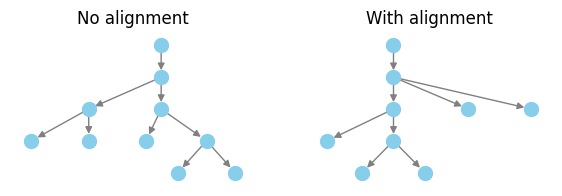

In [63]:
# Visualise means
fig, axes = plt.subplots(1, 2, figsize=(7, 2))

mean_estimate_no_alignment_nx = convert_bhv_tree_to_networkx(
    mean_estimate_no_alignment[0], [1 for _ in range(6)]
)
pos = nx.nx_agraph.graphviz_layout(mean_estimate_no_alignment_nx, prog="dot", root=-1)
nx.draw(
    mean_estimate_no_alignment_nx,
    pos,
    ax=axes[0],
    with_labels=False,
    node_size=100,
    node_color="skyblue",
    font_size=10,
    edge_color="gray",
)
axes[0].set_title("No alignment")

mean_estimate_with_alignment_nx = convert_bhv_tree_to_networkx(
    mean_estimate_with_alignment[0], [1 for _ in range(6)]
)
pos = nx.nx_agraph.graphviz_layout(mean_estimate_with_alignment_nx, prog="dot", root=-1)
nx.draw(
    mean_estimate_with_alignment_nx,
    pos,
    ax=axes[1],
    with_labels=False,
    node_size=100,
    node_color="skyblue",
    font_size=10,
    edge_color="gray",
)
axes[1].set_title("With alignment")


plt.show()

### Find space

In [50]:
def do_u_exist(new_boy, stable_boys, total_space):
    if len(stable_boys) == 0:
        return False

    # print(stable_boys)
    for perm in total_space.aligner.align_algo._perms:
        relabeled = total_space.group_action(perm, new_boy)
        # print(relabeled)
        for stable_tree in stable_boys:
            # print(stable_tree)
            if total_space.metric.dist(stable_tree, relabeled) < 0.1:
                return True
    return False


5
3
{((({0, 3, 5, 6}, {1, 2, 4, 7}),), (np.int64(1),)), ((({0, 1, 4}, {2, 3, 5, 6, 7}),), (np.int64(1),)), ((({0, 1}, {2, 3, 4, 5, 6, 7}),), (np.int64(1),))}
1
1
1


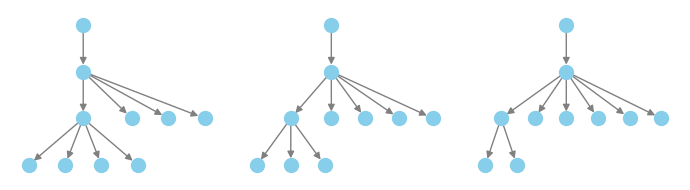

5
{((({0, 3}, {1, 2, 4, 5, 6, 7}), ({0, 2, 3}, {1, 4, 5, 6, 7})), (np.int64(1), np.int64(1))), ((({0, 1, 4}, {2, 3, 5, 6, 7}), ({0, 1, 3, 4, 6, 7}, {2, 5})), (np.int64(1), np.int64(1))), ((({0, 1, 2, 3, 5, 6}, {4, 7}), ({0, 1, 3, 4, 5, 7}, {2, 6})), (np.int64(1), np.int64(1))), ((({0, 2, 4, 7}, {1, 3, 5, 6}), ({0, 1, 2, 4, 7}, {3, 5, 6})), (np.int64(1), np.int64(1))), ((({0, 1, 2, 4, 5, 7}, {3, 6}), ({0, 1, 2, 7}, {3, 4, 5, 6})), (np.int64(1), np.int64(1)))}
2
2
2
2
2


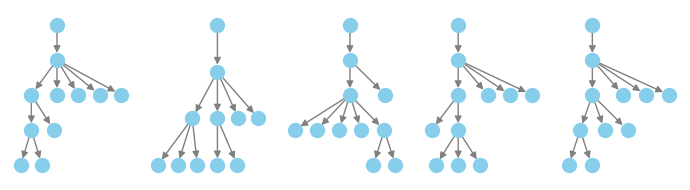

7
{((({0, 2, 3, 4, 6, 7}, {1, 5}), ({0, 4, 6, 7}, {1, 2, 3, 5}), ({0, 1, 4, 5, 6, 7}, {2, 3}), ({0, 6, 7}, {1, 2, 3, 4, 5})), (np.int64(1), np.int64(1), np.int64(1), np.int64(1))), ((({0, 4, 7}, {1, 2, 3, 5, 6}), ({0, 7}, {1, 2, 3, 4, 5, 6}), ({0, 2, 4, 5, 6, 7}, {1, 3}), ({0, 1, 3, 4, 5, 7}, {2, 6})), (np.int64(1), np.int64(1), np.int64(1), np.int64(1))), ((({0, 2, 5}, {1, 3, 4, 6, 7}), ({0, 2, 3, 5, 6, 7}, {1, 4}), ({0, 2, 5, 7}, {1, 3, 4, 6}), ({0, 2, 3, 5, 7}, {1, 4, 6})), (np.int64(1), np.int64(1), np.int64(1), np.int64(1))), ((({0, 1, 4, 5}, {2, 3, 6, 7}), ({0, 2, 3, 4, 6, 7}, {1, 5}), ({0, 1, 4, 5, 6, 7}, {2, 3}), ({0, 1, 2, 3, 4, 5}, {6, 7})), (np.int64(1), np.int64(1), np.int64(1), np.int64(1))), ((({0, 1, 2, 4, 6, 7}, {3, 5}), ({0, 3, 5}, {1, 2, 4, 6, 7}), ({0, 1, 3, 5, 6}, {2, 4, 7}), ({0, 2, 3, 4, 5, 7}, {1, 6})), (np.int64(1), np.int64(1), np.int64(1), np.int64(1))), ((({0, 1, 2, 3, 6, 7}, {4, 5}), ({0, 2, 3, 4, 5, 6}, {1, 7}), ({0, 1, 3, 6, 7}, {2, 4, 5}), ({0, 2, 3, 4, 5

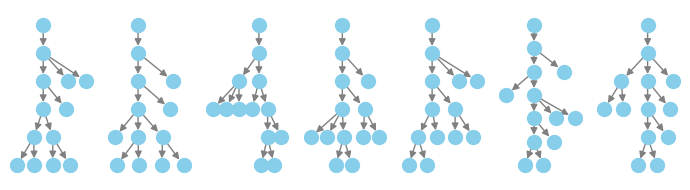

3
{((({0, 2, 4, 6, 7}, {1, 3, 5}), ({0, 1, 2, 3, 5, 7}, {4, 6}), ({0, 2, 7}, {1, 3, 4, 5, 6}), ({0, 2, 4, 5, 6, 7}, {1, 3}), ({0, 2}, {1, 3, 4, 5, 6, 7})), (np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1))), ((({0, 1, 2, 4, 5, 7}, {3, 6}), ({0, 2, 4, 5}, {1, 3, 6, 7}), ({0, 1, 2, 3, 6, 7}, {4, 5}), ({0, 2, 4, 5, 7}, {1, 3, 6}), ({0, 2}, {1, 3, 4, 5, 6, 7})), (np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1))), ((({0, 1, 2, 4, 5, 7}, {3, 6}), ({0, 2, 4, 5, 7}, {1, 3, 6}), ({0, 7}, {1, 2, 3, 4, 5, 6}), ({0, 4, 5, 7}, {1, 2, 3, 6}), ({0, 5, 7}, {1, 2, 3, 4, 6})), (np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1)))}
5
5
5


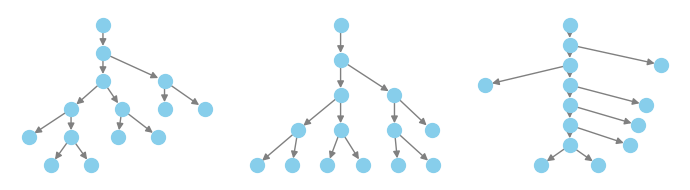

{1: 3, 2: 5, 4: 7, 5: 3}


In [65]:
n_BHV_space = 8

total_space = TreeSpace(n_labels=n_BHV_space)
total_space.equip_with_group_action()
label_invariant_tree_space = total_space.equip_with_quotient()
# print(len(generate_splits(list(range(n_BHV_space)), exclude_singletons=True)))
counts = {}
for i in [1, 2, 4, 5]:  # range(1, n_BHV_space-1):
    stable_boys = set()
    for _ in range(50):
        splits = generate_n_splits(list(range(n_BHV_space)), n_splits=i)
        new_tree = Tree(splits, [1 for _ in range(len(splits))])

        already_exists = do_u_exist(new_tree, stable_boys, total_space)

        if not already_exists:
            stable_boys.add(new_tree)

    print(len(stable_boys))
    print(stable_boys)
    counts[i] = len(stable_boys)

    for sb in stable_boys:
        print(len(sb.topology.splits))

    all_stable_boys_8[i] = stable_boys

    n_cols = len(stable_boys)
    fig, axes = plt.subplots(1, n_cols, figsize=(7, 2))
    for i, (tr) in enumerate(stable_boys):
        ax = axes[i]
        back_to_nx = convert_bhv_tree_to_networkx(tr, [1 for _ in range(n_BHV_space)])
        pos = nx.nx_agraph.graphviz_layout(back_to_nx, prog="dot", root=-1)
        nx.draw(
            back_to_nx,
            pos,
            ax=ax,
            with_labels=False,
            node_size=100,
            node_color="skyblue",
            font_size=10,
            edge_color="gray",
        )

    plt.tight_layout()
    plt.show()

print(counts)

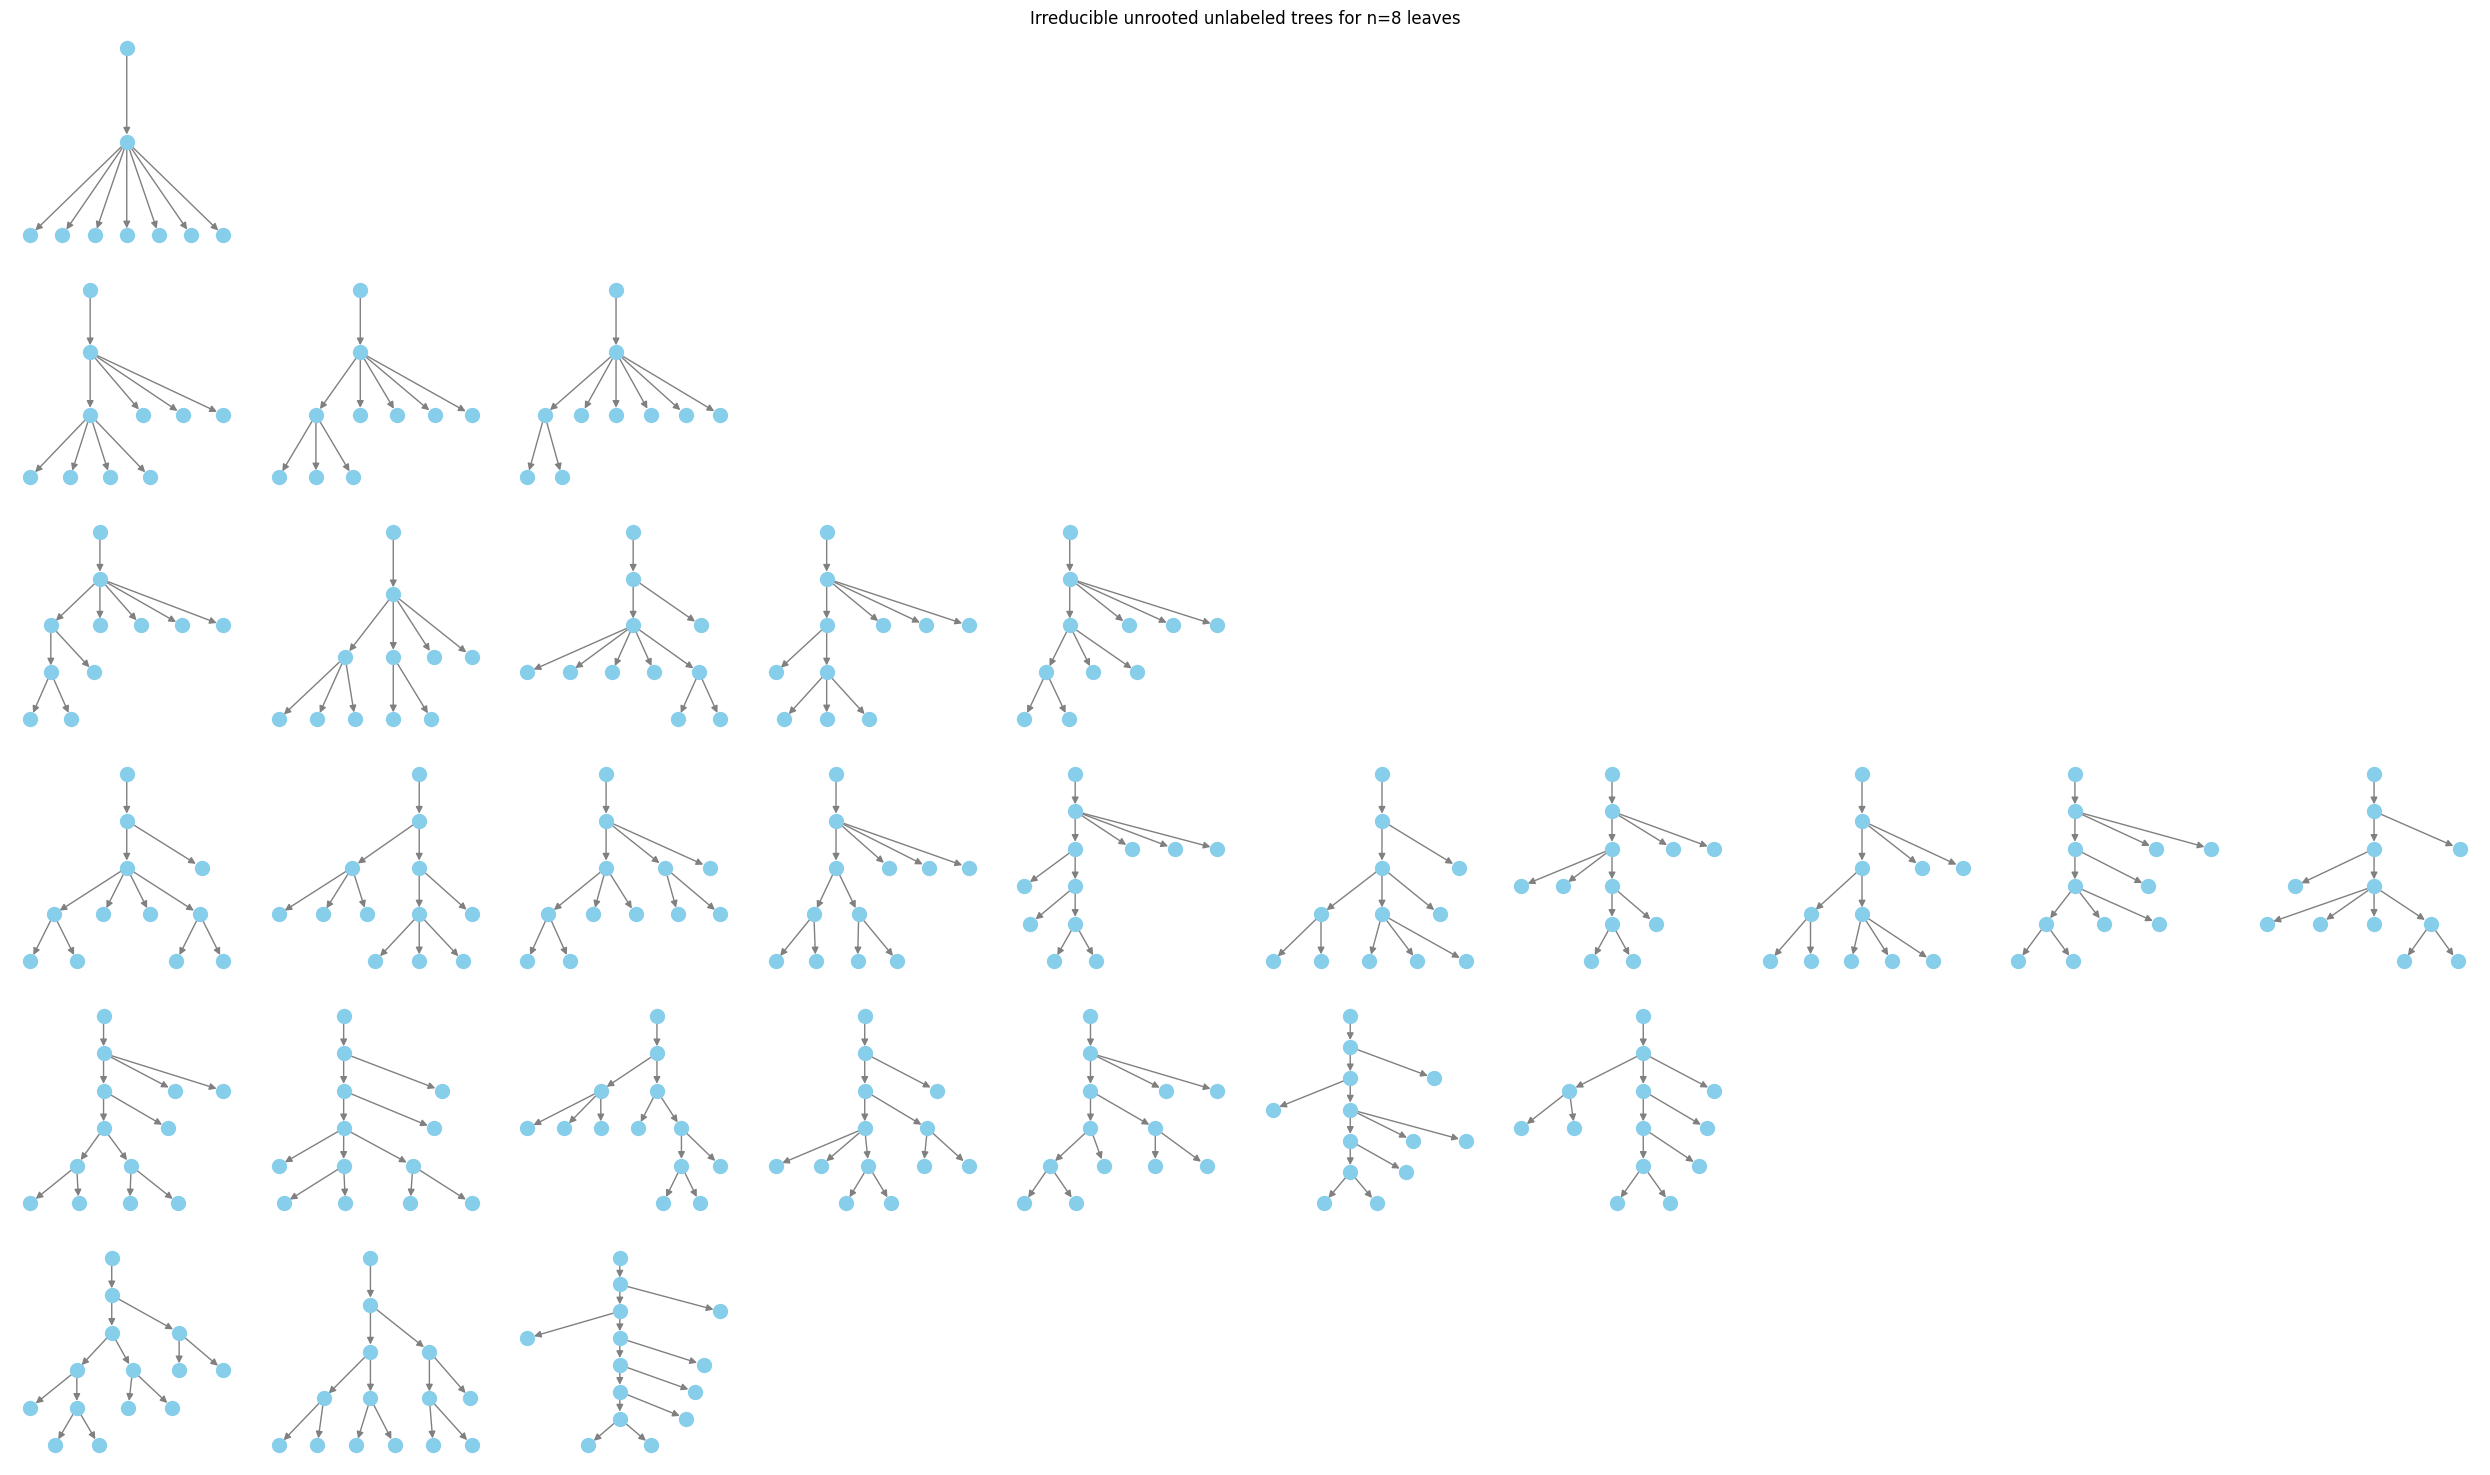

In [78]:
n_rows = len(all_stable_boys_8) + 1
n_cols = 10
fig, axes = plt.subplots(n_rows, n_cols, figsize=(25, 15))

ax = axes[0][0]
star = nx.DiGraph()
for i in range(7):
    star.add_edge(8, i)
star.add_edge(-1, 8)
pos = nx.nx_agraph.graphviz_layout(star, prog="dot", root=-1)
nx.draw(
    star,
    pos,
    ax=ax,
    with_labels=False,
    node_size=100,
    node_color="skyblue",
    font_size=10,
    edge_color="gray",
)

for i in range(1, 6):
    stable_boys_with_i_edges = all_stable_boys_8[i]
    for j, tr in enumerate(stable_boys_with_i_edges):
        ax = axes[i][j]
        back_to_nx = convert_bhv_tree_to_networkx(tr, [1 for _ in range(n_BHV_space)])
        pos = nx.nx_agraph.graphviz_layout(back_to_nx, prog="dot", root=-1)
        nx.draw(
            back_to_nx,
            pos,
            ax=ax,
            with_labels=False,
            node_size=100,
            node_color="skyblue",
            font_size=10,
            edge_color="gray",
        )
for ax in axes.ravel():
    ax.axis("off")
plt.suptitle("Irreducible unrooted unlabeled trees for n=8 leaves")
plt.tight_layout()
plt.show()

### Various sanity checks

#### |N| = 4 

In [2]:
total_space = TreeSpace(n_labels=4)
total_space.equip_with_group_action()
label_invariant_tree_space = total_space.equip_with_quotient()

# 1 and 2 are switched
tree_topo = (Split({0, 1}, {2, 3}),)
permuted_tree_topo = (Split({0, 2}, {1, 3}),)

tree = Tree(tree_topo, [1])
shifted_tree = Tree(tree_topo, [2])
permuted_tree = Tree(permuted_tree_topo, [1])

aligned_permuted_tree = total_space.aligner.align(permuted_tree, tree)
aligned_permuted_tree_to_shifted = total_space.aligner.align(
    permuted_tree, shifted_tree
)
shifted_aligned = total_space.aligner.align(shifted_tree, tree)

print("Tree", tree)
print("Shifted tree", shifted_tree)
print("Permuted tree", permuted_tree)
print("Permuted aligned to tree", aligned_permuted_tree)
print("Permuted aligned to shifted tree", aligned_permuted_tree_to_shifted)
print("Shifted aligned to tree", shifted_aligned)

Tree (({0, 1}|{2, 3});[1])
Shifted tree (({0, 1}|{2, 3});[2])
Permuted tree (({0, 2}|{1, 3});[1])
Permuted aligned to tree (({0, 1}|{2, 3});[1])
Permuted aligned to shifted tree (({0, 1}|{2, 3});[1])
Shifted aligned to tree (({0, 1}|{2, 3});[2])


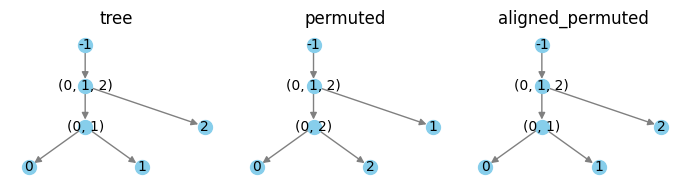

In [ ]:
# Visualise
trees = [tree, permuted_tree, aligned_permuted_tree]
tree_names = ["tree", "permuted", "aligned_permuted"]
n_cols = len(trees)
fig, axes = plt.subplots(1, n_cols, figsize=(7, 2))
for i, (tree) in enumerate(trees):
    ax = axes[i]
    back_to_nx = convert_bhv_tree_to_networkx(tree, [1 for _ in range(4)])
    pos = nx.nx_agraph.graphviz_layout(back_to_nx, prog="dot", root=-1)
    nx.draw(
        back_to_nx,
        pos,
        ax=ax,
        with_labels=True,
        node_size=100,
        node_color="skyblue",
        font_size=10,
        edge_color="gray",
    )
    ax.set_title(tree_names[i])

plt.tight_layout()
plt.show()

#### |N| = 5

In [39]:
total_space = TreeSpace(n_labels=5)
total_space.equip_with_group_action()
label_invariant_tree_space = total_space.equip_with_quotient()

# 3 and 1 are switched
tree_topo = (Split({3, 4}, {0, 1, 2}), Split({0, 1}, {2, 3, 4}))
permuted_tree_topo = (Split({1, 4}, {0, 3, 2}), Split({0, 3}, {2, 1, 4}))
subset_permuted_tree_topo = (Split({3, 1}, {0, 2, 4}),)
lengths = gs.array([1, 2])

tree = Tree(tree_topo, lengths)
shifted_tree = Tree(tree_topo, lengths + 0.5)
permuted_tree = Tree(permuted_tree_topo, lengths)
subset_permuted_tree = Tree(subset_permuted_tree_topo, [1])

aligned_permuted_tree = total_space.aligner.align(permuted_tree, tree)
aligned_subset_permuted_tree = total_space.aligner.align(subset_permuted_tree, tree)
othe_aligned_subset_permuted_tree = total_space.aligner.align(
    subset_permuted_tree, permuted_tree
)

print("Tree", tree)
print("Permuted tree", permuted_tree)
print("Subset permuted tree", subset_permuted_tree)
print("Permuted aligned to tree", aligned_permuted_tree)
print("Subset permuted aligned to tree", aligned_subset_permuted_tree)
print("Subset permuted aligned to permuted", othe_aligned_subset_permuted_tree)

Tree (({0, 1, 2}|{3, 4}, {0, 1}|{2, 3, 4});[1 2])
Permuted tree (({0, 2, 3}|{1, 4}, {0, 3}|{1, 2, 4});[1 2])
Subset permuted tree (({0, 2, 4}|{1, 3});[1])
Permuted aligned to tree (({0, 1, 2}|{3, 4}, {0, 1}|{2, 3, 4});[1 2])
Subset permuted aligned to tree (({0, 1}|{2, 3, 4});[1])
Subset permuted aligned to permuted (({0, 3}|{1, 2, 4});[1])


In [27]:
print(total_space.metric.dist(tree, permuted_tree))
print(total_space.metric.dist(tree, aligned_permuted_tree))
print(label_invariant_tree_space.metric.dist(tree, permuted_tree))

3.23606797749979
1.4142135623730951
1.4142135623730951


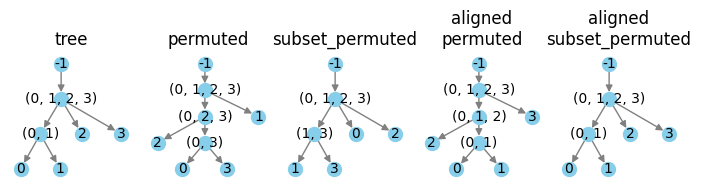

In [25]:
# Visualise
trees = [
    tree,
    permuted_tree,
    subset_permuted_tree,
    aligned_permuted_tree,
    aligned_subset_permuted_tree,
]
tree_names = [
    "tree",
    "permuted",
    "subset_permuted",
    "aligned\npermuted",
    "aligned\nsubset_permuted",
]
n_cols = len(trees)
fig, axes = plt.subplots(1, n_cols, figsize=(7, 2))
for i, (tree) in enumerate(trees):
    ax = axes[i]
    back_to_nx = convert_bhv_tree_to_networkx(tree, [1 for _ in range(5)])
    pos = nx.nx_agraph.graphviz_layout(back_to_nx, prog="dot", root=-1)
    nx.draw(
        back_to_nx,
        pos,
        ax=ax,
        with_labels=True,
        node_size=100,
        node_color="skyblue",
        font_size=10,
        edge_color="gray",
    )
    ax.set_title(tree_names[i])

plt.tight_layout()
plt.show()

In [30]:
fm = SturmsMean(total_space, epsilon=1e-3, max_iter=1000, align_iter=4)

In [49]:
boring_trees = np.array([tree, tree, shifted_tree, shifted_tree])

est = fm.fit(boring_trees).estimate_[0]
print(fm.procrustes_obj(boring_trees, est))
print(est)

# [((({0, 1, 2}, {3, 4}), ({0, 1}, {2, 3, 4})), (np.float64(1.1666666666666667), np.float64(2.1666666666666656)))]

1.414213562373095
(({0, 1, 2}|{3, 4}, {0, 1}|{2, 3, 4});[1.25069638 2.25069638])


In [50]:
trees = np.array([tree, shifted_tree, permuted_tree, permuted_tree])

est_without_align = fm.fit(trees).estimate_[0]
print(fm.procrustes_obj(trees, est_without_align))
print(est_without_align)

est_with_align = fm.align_and_fit(trees).estimate_[0]
print(fm.procrustes_obj(trees, est_with_align))
print(est_with_align)

8.956858257396638
(({0, 1, 2}|{3, 4}, {0, 1}|{2, 3, 4});[0.08103321 0.14585979])
1.0620466556645007
(({0, 1, 2}|{3, 4}, {0, 1}|{2, 3, 4});[1.1254902 2.1254902])


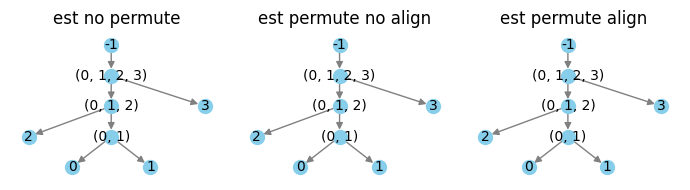

In [ ]:
# Visualise
trees = [est, est_without_align, est_with_align]
tree_names = ["est no permute", "est permute no align", "est permute align"]
n_cols = len(trees)
fig, axes = plt.subplots(1, n_cols, figsize=(7, 2))
for i, (tr) in enumerate(trees):
    ax = axes[i]
    back_to_nx = convert_bhv_tree_to_networkx(tr, [1 for _ in range(5)])
    pos = nx.nx_agraph.graphviz_layout(back_to_nx, prog="dot", root=-1)
    nx.draw(
        back_to_nx,
        pos,
        ax=ax,
        with_labels=True,
        node_size=100,
        node_color="skyblue",
        font_size=10,
        edge_color="gray",
    )
    ax.set_title(tree_names[i])

plt.tight_layout()
plt.show()